# 从代数角度证明两者相等

### 核心：帕塞瓦尔定理

帕塞瓦尔定理保证了：
    时域能量 = 频域能量

$$\sum_{n=0}^{N-1} |x[n]|^2 = \frac{1}{N} \sum_{k=0}^{N-1} |X[k]|^2$$



### 左边：时域平均功率

$$P_{avg} = \frac{1}{N} \sum_{n=0}^{N-1} x[n]^2$$



### 右边：从频域推导

### Step 1：双边功率谱

$$P[k] = \frac{1}{N}|X[k]|^2$$

求和：

$$\sum_{k=0}^{N-1} P[k] = \sum_{k=0}^{N-1} \frac{1}{N}|X[k]|^2 = \frac{1}{N}\sum_{k=0}^{N-1}|X[k]|^2$$

### Step 2：代入帕塞瓦尔定理

$$\sum_{k=0}^{N-1} P[k] = \frac{1}{N}\sum_{n=0}^{N-1}|x[n]|^2 = P_{avg}$$

### Step 3：双边 → 单边

实信号频谱共轭对称：

$$P[k] = P[N-k]$$

所以：

$$\sum_{k=0}^{N-1} P[k] = P[0] + \sum_{k=1}^{N/2-1} 2P[k] + P[N/2] = \sum P_{single}[k]$$

### 得证

$$\boxed{\sum_{k=0}^{N/2} P_{single}[k] = \frac{1}{N}\sum_{n=0}^{N-1} x[n]^2}$$


## 数值验证


In [69]:
import numpy as np

def sampling(t, N):
    x = np.sin(2*np.pi*50*t) + 0.3 * np.random.randn(N)
    return x

N = 512
t = np.arange(N) / 1000
x = sampling(t, N)

# 时域
P_avg_time = np.mean(x**2)

# 频域
X = np.fft.fft(x) # FFT
P = (1/N) * np.abs(X)**2 # 双边功率谱
P_avg_freq_two = np.sum(P) / N

P_single = P[:N//2+1].copy()
P_single[1:-1] *= 2      # 单边功率谱
P_avg_freq_one = np.sum(P_single) / N

print(f"时域的平均功率:     {P_avg_time:.10f}")
print(f"频域双边平均功率:    {P_avg_freq_two:.10f}")
print(f"频域单边平均功率:    {P_avg_freq_one:.10f}")


时域的平均功率:     0.5881079676
频域双边平均功率:    0.5881079676
频域单边平均功率:    0.5881079676


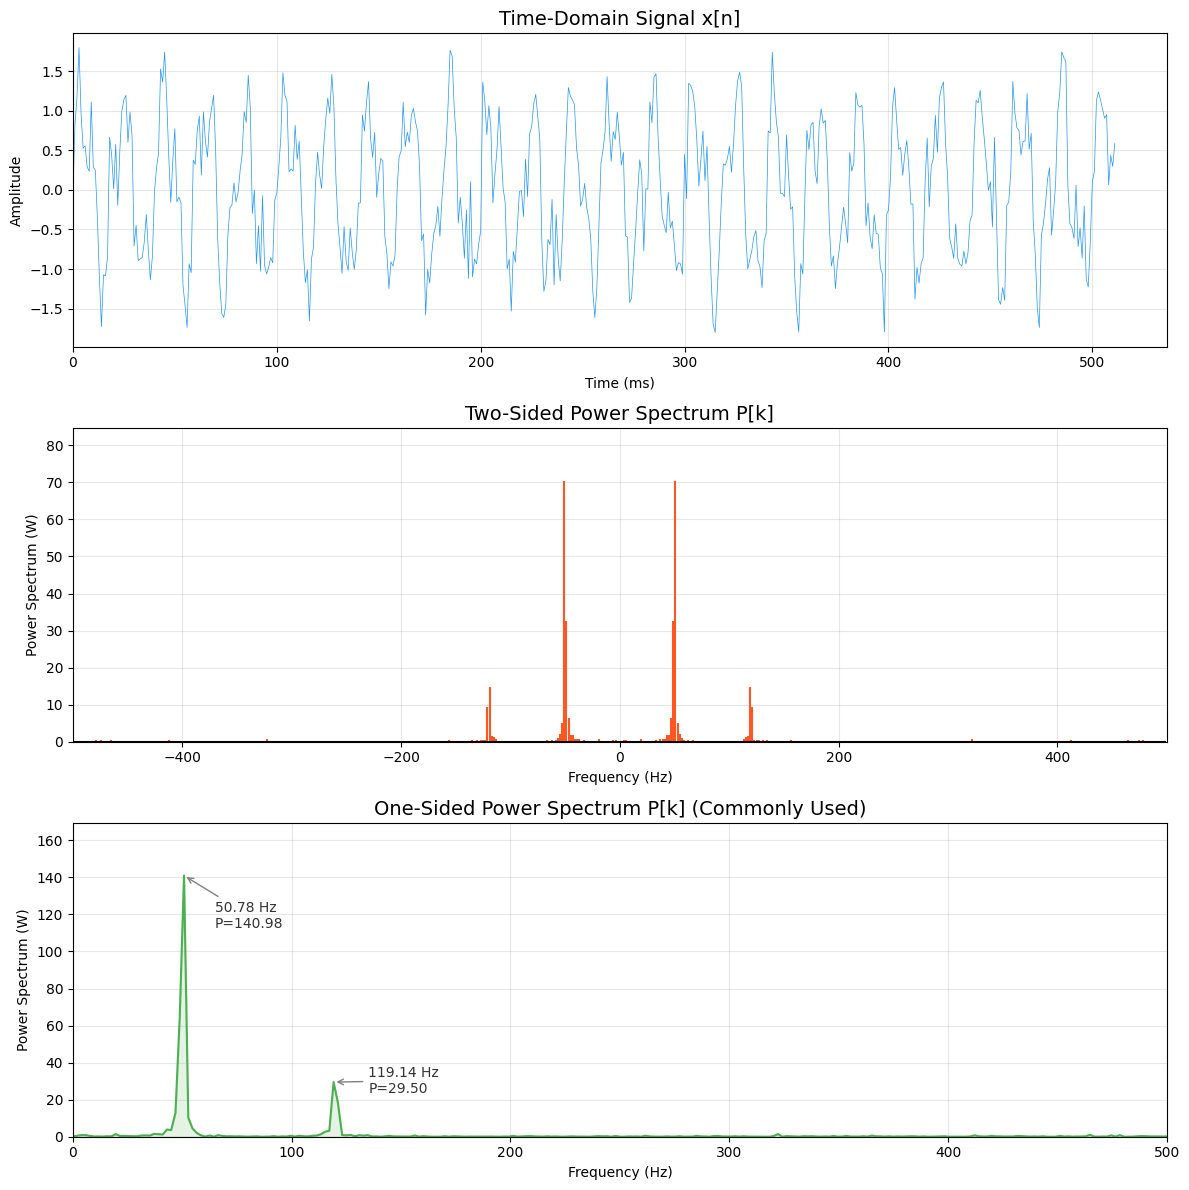

Time-domain average power: 0.696676
Freq-domain average power: 0.696676
Difference: 1.11e-16


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 连续信号发生器: 50Hz + 120Hz 正弦 + 噪声
def sampling(t,N):
    x = 1.0 * np.sin(2 * np.pi * 50 * t) + \
            0.5 * np.sin(2 * np.pi * 120 * t) + \
            0.3 * np.random.randn(N)
    return x

# 信号采样
fs = 1000          # 采样频率 1000 Hz
nyquist = fs / 2   # Nyquist 频率
N = 512            # 采样点数
t = np.arange(N) / fs # 每个采样点的真实时间


# 正式信号采样
signal = sampling(t, N)


# FFT
X = np.fft.fft(signal)
# 双边功率谱
P_two = (1 / N) * np.abs(X)**2
freqs = np.fft.fftfreq(N, 1/fs) # 双边频率轴
# 单边功率谱
# half = N // 2
# P_single = P_two[:half+1].copy()
# P_single[1:-1] *= 2 # DC和Nyquist频率不翻倍
# freqs_single = freqs[0:half+1] # 单边频率轴

X_single = np.fft.rfft(signal)
P_single = (1 / N) * np.abs(X_single)**2
P_single[1:-1] *= 2 # DC和Nyquist频率不翻倍
freqs_single = np.fft.rfftfreq(N, 1/fs) # 单边频率轴

# 绘图
fig, axes = plt.subplots(3, 1, figsize=(12, 12))
# --- 时域波形 ---
axes[0].plot(t * 1000, signal, linewidth=0.5, color='#2196F3')
axes[0].set_title('Time-Domain Signal x[n]', fontsize=14)
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0)

# --- 双边功率谱 ---
axes[1].stem(freqs, P_two, linefmt='#FF5722', markerfmt=' ', basefmt='k-')
axes[1].set_title('Two-Sided Power Spectrum P[k]', fontsize=14)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Power Spectrum (W)')
axes[1].set_xlim(-nyquist, nyquist)
axes[1].set_ylim(0, 1.2 * np.max(P_two))
axes[1].grid(True, alpha=0.3)

# --- 单边功率谱（实际常用）---
axes[2].plot(freqs_single, P_single, color='#4CAF50', linewidth=1.5)
axes[2].fill_between(freqs_single, P_single, alpha=0.15, color='#4CAF50')
axes[2].set_title('One-Sided Power Spectrum P[k] (Commonly Used)', fontsize=14)
axes[2].set_xlabel('Frequency (Hz)')
axes[2].set_ylabel('Power Spectrum (W)')
axes[2].set_xlim(0, nyquist)
axes[2].set_ylim(0, 1.2 * np.max(P_single))
axes[2].grid(True, alpha=0.3)

# 标注峰值
for k in [50, 120]:
    # 找到最近目标频率的索引
    idx = np.argmin(np.abs(freqs_single - k))
    axes[2].annotate(f'{freqs_single[idx]:.2f} Hz\nP={P_single[idx]:.2f}', # 标注峰值
                     xy=(freqs_single[idx], P_single[idx]), # 箭头指向的点
                     xytext=(k + 15, P_single[idx] * 0.8), # 文字放的位置
                     arrowprops=dict(arrowstyle='->', color='gray'), # 箭头属性
                     fontsize=10, color='#333') # 字体大小和颜色

plt.tight_layout()
# plt.savefig('fig.png', dpi=300)    # 论文/印刷常用
plt.show()

# 验证帕塞瓦尔定理
P_avg_time = np.mean(signal**2)
P_avg_freq = np.sum(P_single) / N
print(f"Time-domain average power: {P_avg_time:.6f}")
print(f"Freq-domain average power: {P_avg_freq:.6f}")
print(f"Difference: {abs(P_avg_time - P_avg_freq):.2e}")


# periodogram 和 welch 的区别

| 分类 | 函数 | 切段 | 每段计算 | 最后一步 |
|-----|------|------|----------|----------|
|PSD | periodogram, density | 不切，整段 | $\frac{1}{N \cdot f_s}\|X\|^2$ | 无 |
|Power | periodogram, spectrum | 不切，整段 | $\frac{1}{N}\|X\|^2$ | 无 |
|PSD | welch, density | 切多段 | $\frac{1}{nperseg \cdot f_s}\|X_i\|^2$ | 多段平均 |
|Power | welch, spectrum | 切多段 | $\frac{1}{nperseg}\|X_i\|^2$ | 多段平均 |


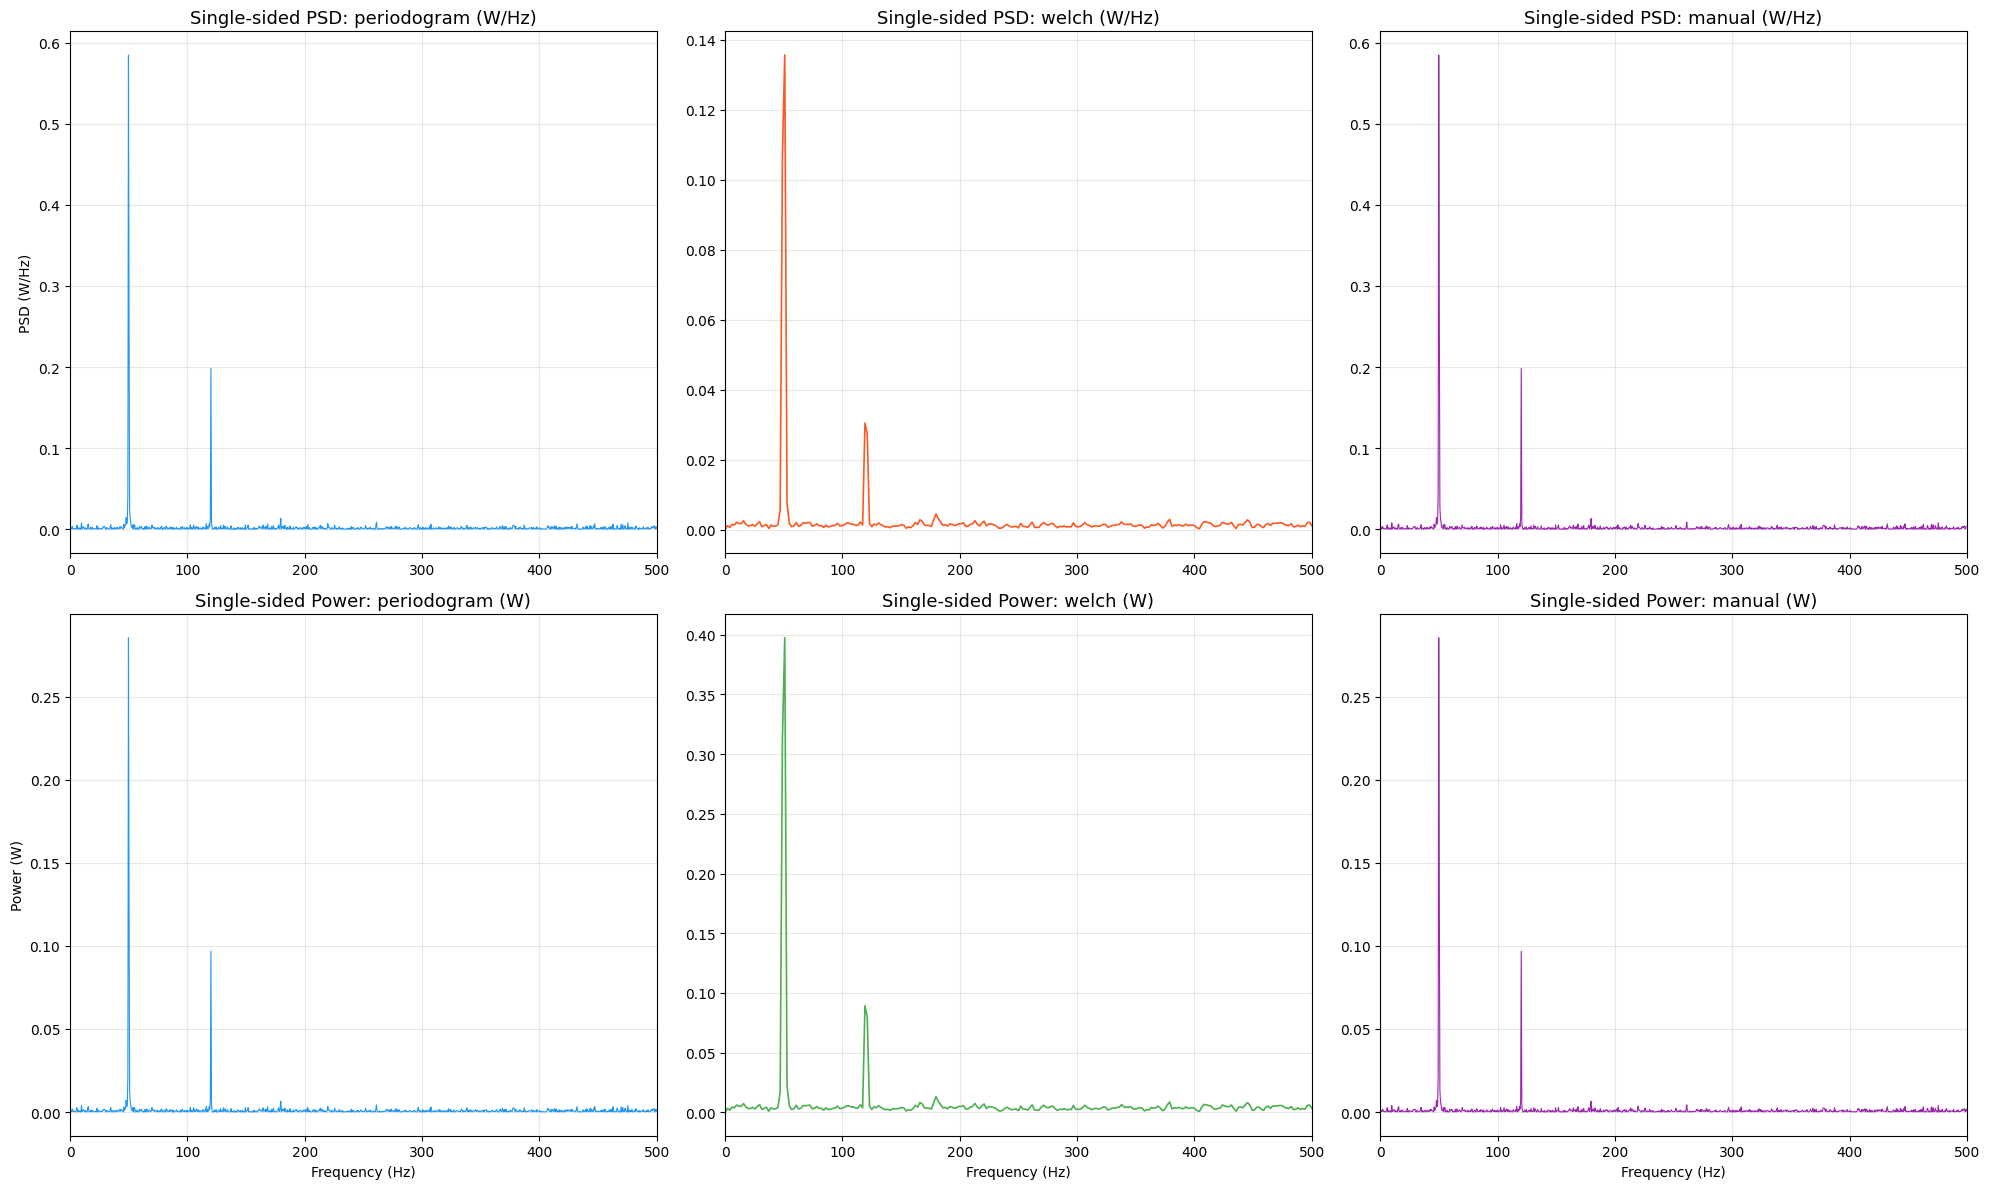

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import periodogram, welch

# ============ 连续信号发生器 ============
def sampling(t, N):
    x = 1 * np.sin(2*np.pi*50*t) + \
        0.5 * np.sin(2*np.pi*120*t) + \
        0.8 * np.random.randn(N)
    return x

# ============ 采样参数 ============
fs = 1000             # 采样频率 1000 Hz
nyquist = fs / 2      # Nyquist 频率 500 Hz
N = 2048              # 采样点数
t = np.arange(N) / fs # 每个采样点的真实时间
x = sampling(t, N)


# ============ 单边 功率谱密度 PSD ============
f1, PSD_per = periodogram(x, fs=fs)               # 周期图法：默认就是 scaling='density'
f2, PSD_wel = welch(x, fs=fs, nperseg=512)        # 韦尔奇方法：默认就是 scaling='density'
# 手动验证 PSD
X = np.fft.fft(x)
PSD_manual = (1 / (N * fs)) * np.abs(X)**2
# 转单边
half = N // 2
f3 = np.fft.fftfreq(N, 1/fs)[:half+1]
PSD_manual_single = PSD_manual[:half+1].copy()
PSD_manual_single[1:-1] *= 2


# ============ 单边 Power 功率谱 ============
f4, P_per = periodogram(x, fs=fs, scaling='spectrum')          # spectrum: 功率谱
f5, P_wel = welch(x, fs=fs, nperseg=512, scaling='spectrum')   # spectrum: 功率谱
# 手动验证功率谱
# X = np.fft.fft(x)
# P_manual = (1 / N) * np.abs(X)**2
# # 转单边
# half = N // 2
# f6 = np.fft.fftfreq(N, 1/fs)[:half+1]
# P_manual_single = P_manual[:half+1].copy()
# P_manual_single[1:-1] *= 2

f6 = np.fft.rfftfreq(N, 1/fs)
P_manual_single = (1 / N) * np.fft.rfft(x)
P_manual_single = np.abs(P_manual_single)**2
P_manual_single[1:-1] *= 2


# ============ 绘图 ============
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

axes[0,0].plot(f1, PSD_per, color='#2196F3', linewidth=0.8)
axes[0,0].set_title('Single-sided PSD: periodogram (W/Hz)', fontsize=13)
axes[0,0].set_ylabel('PSD (W/Hz)')
axes[0,0].set_xlim(0, nyquist)
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(f2, PSD_wel, color='#FF5722', linewidth=1.2)
axes[0,1].set_title('Single-sided PSD: welch (W/Hz)', fontsize=13)
axes[0,1].set_xlim(0, nyquist)
axes[0,1].grid(True, alpha=0.3)

axes[0,2].plot(f3[:-1], PSD_manual_single[:-1], color='#9C27B0', linewidth=0.8)
axes[0,2].set_title('Single-sided PSD: manual (W/Hz)', fontsize=13)
axes[0,2].set_xlim(0, nyquist)
axes[0,2].grid(True, alpha=0.3)


axes[1,0].plot(f4, P_per, color='#2196F3', linewidth=0.8)
axes[1,0].set_title('Single-sided Power: periodogram (W)', fontsize=13)
axes[1,0].set_xlabel('Frequency (Hz)')
axes[1,0].set_ylabel('Power (W)')
axes[1,0].set_xlim(0, nyquist)
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(f5, P_wel, color='#4CAF50', linewidth=1.2)
axes[1,1].set_title('Single-sided Power: welch (W)', fontsize=13)
axes[1,1].set_xlabel('Frequency (Hz)')
axes[1,1].set_xlim(0, nyquist)
axes[1,1].grid(True, alpha=0.3)

axes[1,2].plot(f6, P_manual_single, color='#9C27B0', linewidth=0.8)
axes[1,2].set_title('Single-sided Power: manual (W)', fontsize=13)
axes[1,2].set_xlabel('Frequency (Hz)')
axes[1,2].set_xlim(0, nyquist)
axes[1,2].grid(True, alpha=0.3)



plt.tight_layout()
plt.show()


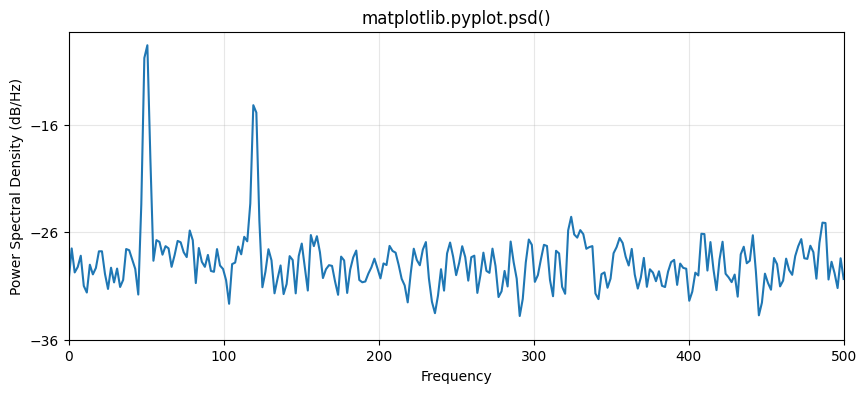

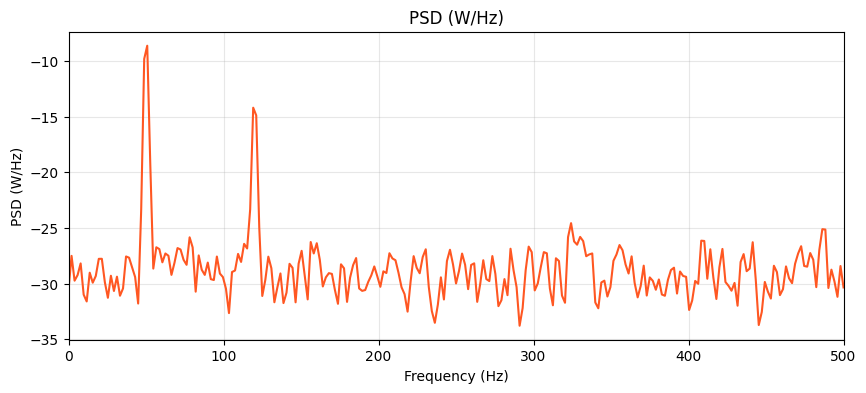

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============ 信号 ============
def sampling(t, N):
    x = 1 * np.sin(2*np.pi*50*t) + \
        0.5 * np.sin(2*np.pi*120*t) + \
        0.8 * np.random.randn(N)
    return x

fs = 1000
N = 2048
t = np.arange(N) / fs
x = sampling(t, N)

# ============ 方法1: matplotlib.psd() ============
plt.figure(figsize=(10, 4))
# 这行代码调用的是 Welch 方法（韦尔奇法）来估计信号的功率谱密度（PSD, Power Spectral Density）
plt.psd(x, Fs=fs, NFFT=512, noverlap=256)
plt.title('matplotlib.pyplot.psd()')
plt.grid(True, alpha=0.3)
plt.xlim(0, fs/2)
plt.show()

# ============ 方法2: 只取数据不画图 ============
Pxx, freqs = plt.psd(x, Fs=fs, NFFT=512, noverlap=256)
plt.close()  # 关掉自动生成的图

# Pxx 就是 PSD 数值，freqs 就是频率轴
# 自己画
plt.figure(figsize=(10, 4))
plt.plot(freqs, 10*np.log10(Pxx), color='#FF5722')
plt.title('PSD (W/Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (W/Hz)')
plt.xlim(0, fs/2)
plt.grid(True, alpha=0.3)
plt.show()


# `plt.psd()` 详细解析

## 函数签名

```python
plt.psd(x, Fs=fs, NFFT=512, noverlap=256)
```

这行代码调用的是 **Welch 方法**（韦尔奇法）来估计信号的功率谱密度（PSD, Power Spectral Density）。

---

## 四个参数逐个拆解

### 1. `x` — 输入信号

就是你生成的 2048 点时域信号，包含 50Hz 正弦 + 120Hz 正弦 + 高斯白噪声。

### 2. `Fs=1000` — 采样频率

- 单位：Hz
- 告诉函数信号每秒采 1000 个点
- 用于将频率轴的 bin 索引转换为实际频率值
- 也决定了频谱显示范围：`0 ~ Fs/2 = 500 Hz`

### 3. `NFFT=512` — FFT 点数（每段长度）

核心参数。Welch 方法不是对整段信号做一次 FFT，而是把信号切成**小段**，每段长度为 `NFFT`：

```
信号总长度 N = 2048
每段长度    NFFT = 512
```

对每段做 512 点 FFT，得到该段的频谱，然后多段平均。

**为什么分段？**
- 单次 FFT 的频谱估计方差很大（噪声起伏剧烈）
- 分段后取平均，方差降低，谱线更平滑
- 代价是**频率分辨率下降**（从 N/2 个 bin 变成 NFFT/2 个 bin）

### 4. `noverlap=256` — 段间重叠点数

相邻两段之间重叠 256 个点，即每段向前滑动：

```
步长 stride = NFFT - noverlap = 512 - 256 = 256
```

信号被切成这样的片段：

```
信号:  [0----------------------------------------2047]

段1:   [0=========511]
段2:        [256=========767]
段3:             [512=========1023]
段4:                  [768=========1279]
段5:                       [1024=========1535]
段6:                            [1540=========2047]
```

**为什么重叠？**
- 加窗（默认 Hann 窗）会让每段的**两端数据权重降低**
- 50% 重叠恰好让被前一段"衰减"的数据在后一段得到"补偿"
- 不增加计算量的前提下，有效数据利用率更高
- 增加平均次数，进一步降低方差

---

## 完整计算流程

```
┌─────────────────────────────────────────────────┐
│  原始信号 x (2048 点)                            │
└──────────────────────┬──────────────────────────┘
                       │
          ┌────────────▼────────────┐
          │  滑动窗口切段            │
          │  段长=512, 步长=256      │
          │  得到 7 段              │
          └────────────┬────────────┘
                       │
          ┌────────────▼────────────┐
          │  每段 × Hann 窗         │
          │  (抑制频谱泄漏)          │
          └────────────┬────────────┘
                       │
          ┌────────────▼────────────┐
          │  每段做 512 点 FFT       │
          │  得到 7 个复数频谱       │
          └────────────┬────────────┘
                       │
          ┌────────────▼────────────┐
          │  每段算功率谱            │
          │  P_k = |X_k|²           │
          └────────────┬────────────┘
                       │
          ┌────────────▼────────────┐
          │  7 段取平均              │
          │  P_avg = mean(P_1..P_7)  │
          └────────────┬────────────┘
                       │
          ┌────────────▼────────────┐
          │  归一化 → dB 刻度        │
          │  10·log₁₀(P_avg)        │
          └────────────┬────────────┘
                       │
                       ▼
              绘制 PSD 曲线
              x轴: 0 ~ 500 Hz
              y轴: dB/Hz
```

---

## 段数的计算

```python
段数 = 1 + floor((N - NFFT) / stride)
     = 1 + floor((2048 - 512) / 256)
     = 1 + 6
     = 7 段
```

7 段平均，方差大约降为单段的 **1/7**。

---

## 频率分辨率

| 指标 | 值 | 含义 |
|---|---|---|
| 频率分辨率 | `Fs / NFFT = 1000/512 ≈ 1.95 Hz` | 能区分的最小频率间隔 |
| 输出点数 | `NFFT/2 + 1 = 257` | 0~500 Hz 共 257 个频率点 |
| 最大频率 | `Fs/2 = 500 Hz` | Nyquist 频率 |

如果用 `NFFT=2048`（不分段），频率分辨率可达 `1000/2048 ≈ 0.49 Hz`，但谱线会很噪。

---

## 直观理解

把 `plt.psd()` 想象成：

> 拿一个 **512 点的窗口**，在信号上**每次滑 256 点**地扫过去，对每个窗口"听"一下频率成分，最后把 7 次"听到"的结果**取平均**，画出一条平滑的功率谱曲线。

这就是 Welch 方法的核心思想：**用频率分辨率换谱线平滑度**。

### Power Spectrum (PS) 功率谱

In [73]:
import numpy as np
from scipy.signal import periodogram

# 连续信号
def sampling(t, N):
    return np.sin(2*np.pi*50*t) + 0.3*np.random.randn(N)

# 采样
fs = 1000
nyquist = fs / 2  # Nyquist 频率: 500 Hz
N = 2048
t = np.arange(N) / fs
x = sampling(t, N)

# 单边功率谱 Single Power Spectrum
f_one, P_one = periodogram(x, fs=fs, scaling='spectrum') # 默认单边
# 双边功率谱 Double Power Spectrum
f_two, P_two = periodogram(x, fs=fs, scaling='spectrum', return_onesided=False)

# 验证：单边 = 双边 × 2（除 DC 和 Nyquist）
half = N // 2
P_one_check = P_two[:half+1].copy()
P_one_check[1:-1] *= 2

print(np.allclose(P_one, P_one_check))  # True
print(f"单边功率谱长度: {len(f_one)}")    # 1025 = N//2 + 1 
print(f"双边功率谱长度: {len(f_two)}")    # 2048 = N


True
单边功率谱长度: 1025
双边功率谱长度: 2048


### Power Spectral Density (PSD) 功率谱密度

In [74]:
import numpy as np
from scipy.signal import periodogram
# 连续信号
def sampling(t, N):
    return np.sin(2*np.pi*50*t) + 0.3*np.random.randn(N)
    
# 采样
fs = 1000
nyquist = fs / 2  # Nyquist 频率: 500 Hz
N = 2048
t = np.arange(N) / fs
x = sampling(t, N)

# 单边功率谱密度 Single Power Spectral Density
f_one, S_one = periodogram(x, fs=fs) # 默认单边
# 双边功率谱密度 Double Power Spectral Density
f_two, S_two = periodogram(x, fs=fs, return_onesided=False)

# 验证：单边 = 双边 × 2（除 DC 和 Nyquist）
half = N // 2
S_one_check = S_two[:half+1].copy()
S_one_check[1:-1] *= 2

print(np.allclose(S_one, S_one_check))  # True
print(f"单边功率谱密度长度: {len(f_one)}")    # 1025 = N//2 + 1
print(f"双边功率谱密度长度: {len(f_two)}")    # 2048 = N


True
单边功率谱密度长度: 1025
双边功率谱密度长度: 2048


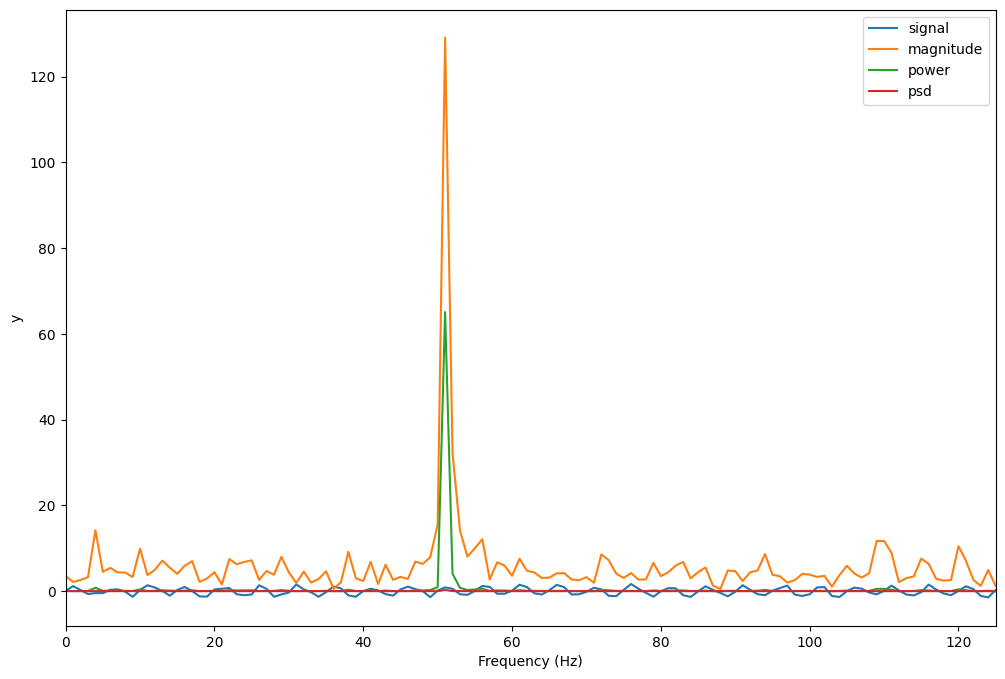

In [98]:
import numpy as np
from scipy.signal import periodogram
# 连续信号
def sampling(t, N):
    return np.sin(2*np.pi*50*t) + 0.3*np.random.randn(N)
    
# 采样
fs = 250
nyquist = fs / 2  # Nyquist 频率: 500 Hz
N = 256
t = np.arange(N) / fs
x = sampling(t, N)

# X[k]：完整的复数频谱（含幅度 + 相位）
X = np.fft.fft(x)

"""
X[k]
 │
 ├─→ np.abs(X)              → 幅度谱
 │
 ├─→ np.angle(X)            → 相位谱
 │
 ├─→ (1/N)    · |X[k]|²     → 功率谱 P[k]      (W)
 │
 └─→ (1/(N·fs)) · |X[k]|²  → 功率谱密度 PSD   (W/Hz)
                                      ↑
                                 多除一个 fs

"""

# 从 X[k] 推出所有量
magnitude = np.abs(X)                # 幅度谱
phase     = np.angle(X)              # 相位谱
power     = (1/N) * np.abs(X)**2     # 功率谱
psd       = (1/(N*fs)) * np.abs(X)**2  # 功率谱密度

fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(x, label="signal")
ax.plot(magnitude, label="magnitude")
ax.plot(power, label="power")
ax.plot(psd, label="psd")
ax.legend()

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("y")

ax.legend()

ax.set_xlim(0, nyquist)

plt.show()

Max error: 8.88e-16


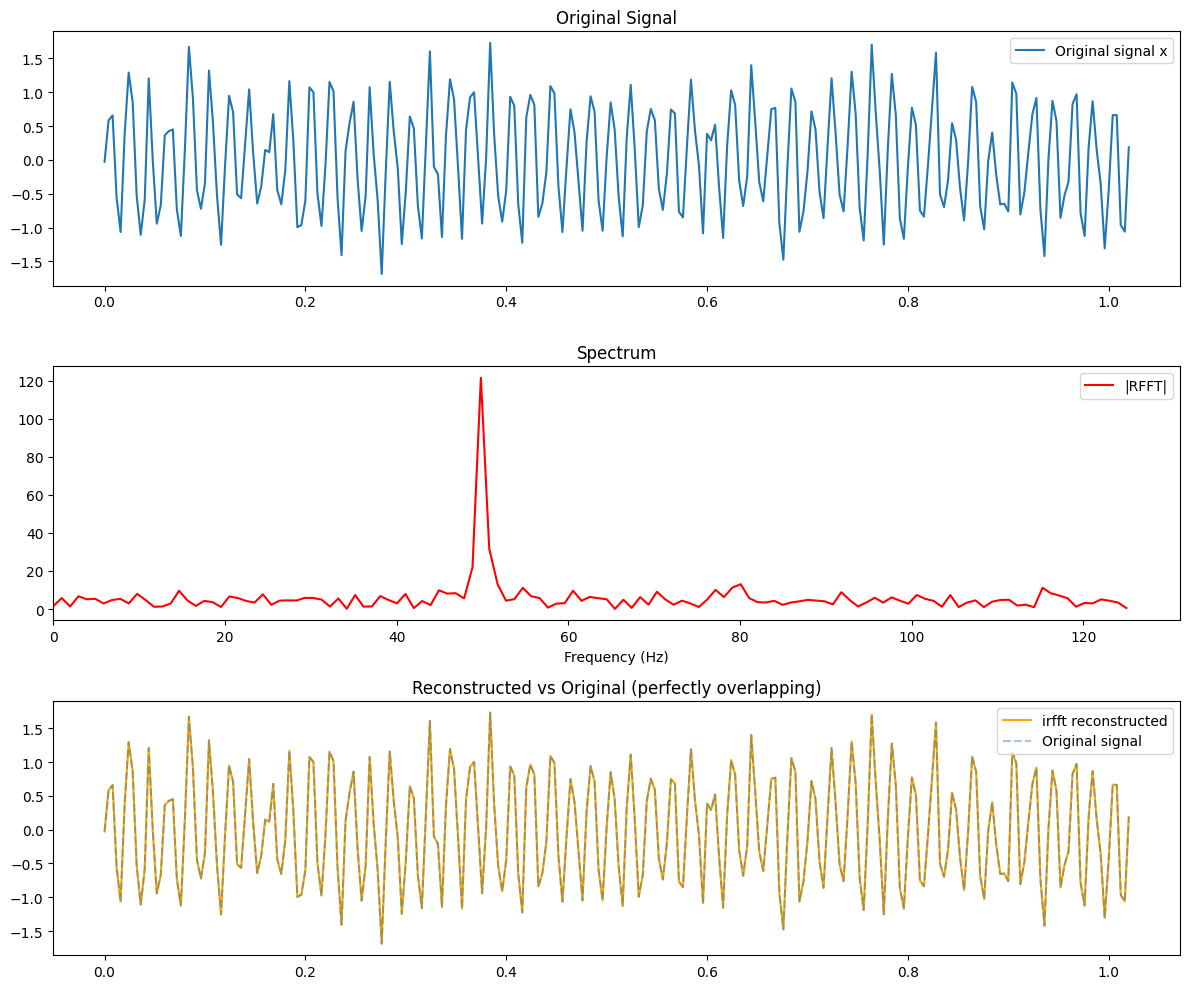

In [27]:
import numpy as np
from matplotlib import pyplot as plt

# 连续信号
def sampling(t, N):
    x = np.sin(2*np.pi*50*t) + 0.3*np.random.randn(N)
    return x

# 采样
fs = 250
N = 256
t = np.arange(N) / fs
x = sampling(t, N)


# 正变换
X_single = np.fft.rfft(x)
f_single = np.fft.rfftfreq(N, d=1/fs)

# 反变换 —— 关键就这一行
# n=N 指定输出长度，否则 irfft 会默认用 2*(len(X)-1)
x_reconstructed = np.fft.irfft(X_single, n=N)

# 验证误差
print(f"Max error: {np.max(np.abs(x - x_reconstructed)):.2e}")

# 绘图
fig, ax = plt.subplots(3, 1, figsize=(12, 10))

ax[0].plot(t, x, label="Original signal x")
ax[0].set_title("Original Signal")
ax[0].legend()

ax[1].plot(f_single, np.abs(X_single), label="|RFFT|", color="r")
ax[1].set_title("Spectrum")
ax[1].set_xlabel("Frequency (Hz)")
ax[1].legend()
ax[1].set_xlim(0)

ax[2].plot(t, x_reconstructed, label="irfft reconstructed", color="orange")
ax[2].plot(t, x, label="Original signal", alpha=0.4, linestyle="--")
ax[2].set_title("Reconstructed vs Original (perfectly overlapping)")
ax[2].legend()

plt.tight_layout()
plt.show()


Max error: 6.00e-15


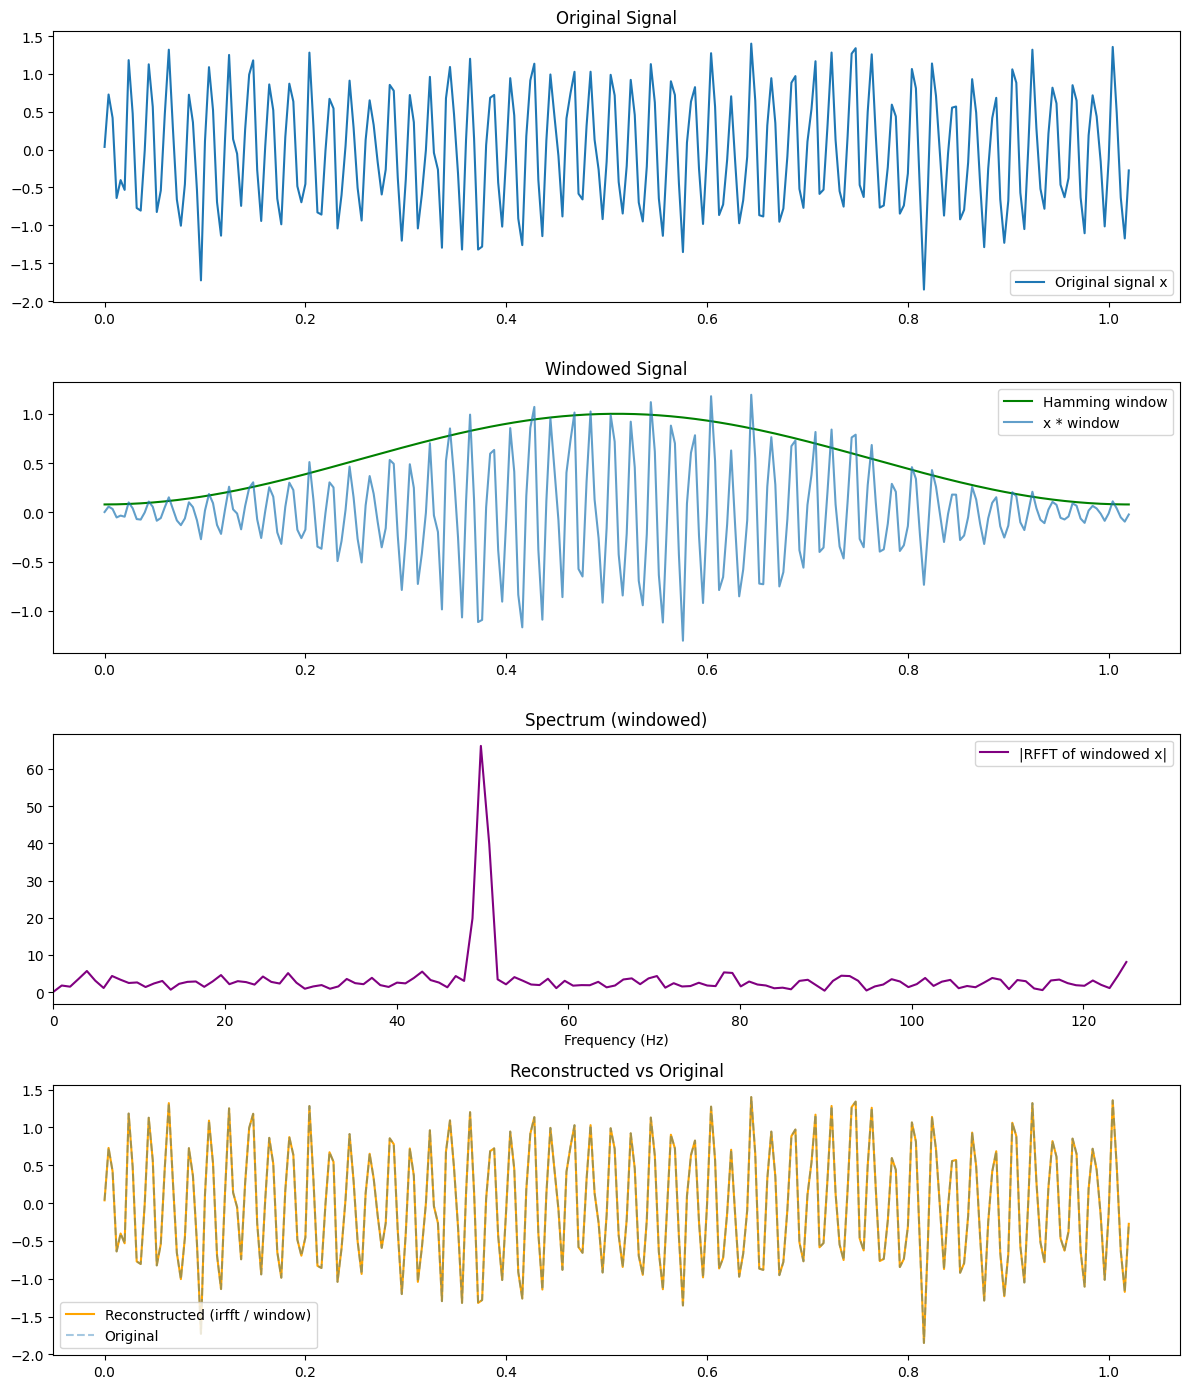

In [29]:
import numpy as np
from matplotlib import pyplot as plt

# 连续信号
def sampling(t, N):
    x = np.sin(2*np.pi*50*t) + 0.3*np.random.randn(N)
    return x

# 采样
fs = 250
N = 256
t = np.arange(N) / fs
x = sampling(t, N)

# Hamming 窗
window = np.hamming(N)

# 正变换（加窗）
x_windowed = x * window
X_windowed = np.fft.rfft(x_windowed)
f_single = np.fft.rfftfreq(N, d=1/fs)

# 反变换
x_rec_windowed = np.fft.irfft(X_windowed, n=N)  # 得到的是 x * window

# 关键：除以窗函数还原原始信号
# 窗函数边缘接近0，直接除会放大噪声，加个很小的阈值保护
window_safe = np.where(window < 1e-6, 1e-6, window)
x_reconstructed = x_rec_windowed / window_safe

# 验证误差
print(f"Max error: {np.max(np.abs(x - x_reconstructed)):.2e}")

# 绘图
fig, ax = plt.subplots(4, 1, figsize=(12, 14))

ax[0].plot(t, x, label="Original signal x")
ax[0].set_title("Original Signal")
ax[0].legend()

ax[1].plot(t, window, color="green", label="Hamming window")
ax[1].plot(t, x_windowed, label="x * window", alpha=0.7)
ax[1].set_title("Windowed Signal")
ax[1].legend()

ax[2].plot(f_single, np.abs(X_windowed), label="|RFFT of windowed x|", color="purple")
ax[2].set_title("Spectrum (windowed)")
ax[2].set_xlabel("Frequency (Hz)")
ax[2].legend()
ax[2].set_xlim(0)

ax[3].plot(t, x_reconstructed, label="Reconstructed (irfft / window)", color="orange")
ax[3].plot(t, x, label="Original", alpha=0.4, linestyle="--")
ax[3].set_title("Reconstructed vs Original")
ax[3].legend()

plt.tight_layout()
plt.show()
